
V1 TPV Overall Analysis
TPV CSV: /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/TPV/Wearable_v1_BVP_TPV_noQC.csv
Detected TPV features: ['TPV0', 'TPV1', 'TPV2', 'TPV3', 'TPV4', 'TPV5', 'TPV6', 'TPV7', 'TPV8', 'TPV9', 'TPV10', 'TPV11', 'TPV12', 'TPV13', 'TPV14', 'TPV15', 'TPV16', 'TPV17', 'TPV18', 'TPV19', 'TPV20', 'TPV21', 'TPV22', 'TPV23', 'TPV24', 'TPV25', 'TPV26', 'TPV27', 'TPV28', 'TPV29', 'TPV30', 'TPV31', 'TPV32']
Total TPV features: 33
state
normal    473
stress    196
Name: count, dtype: int64


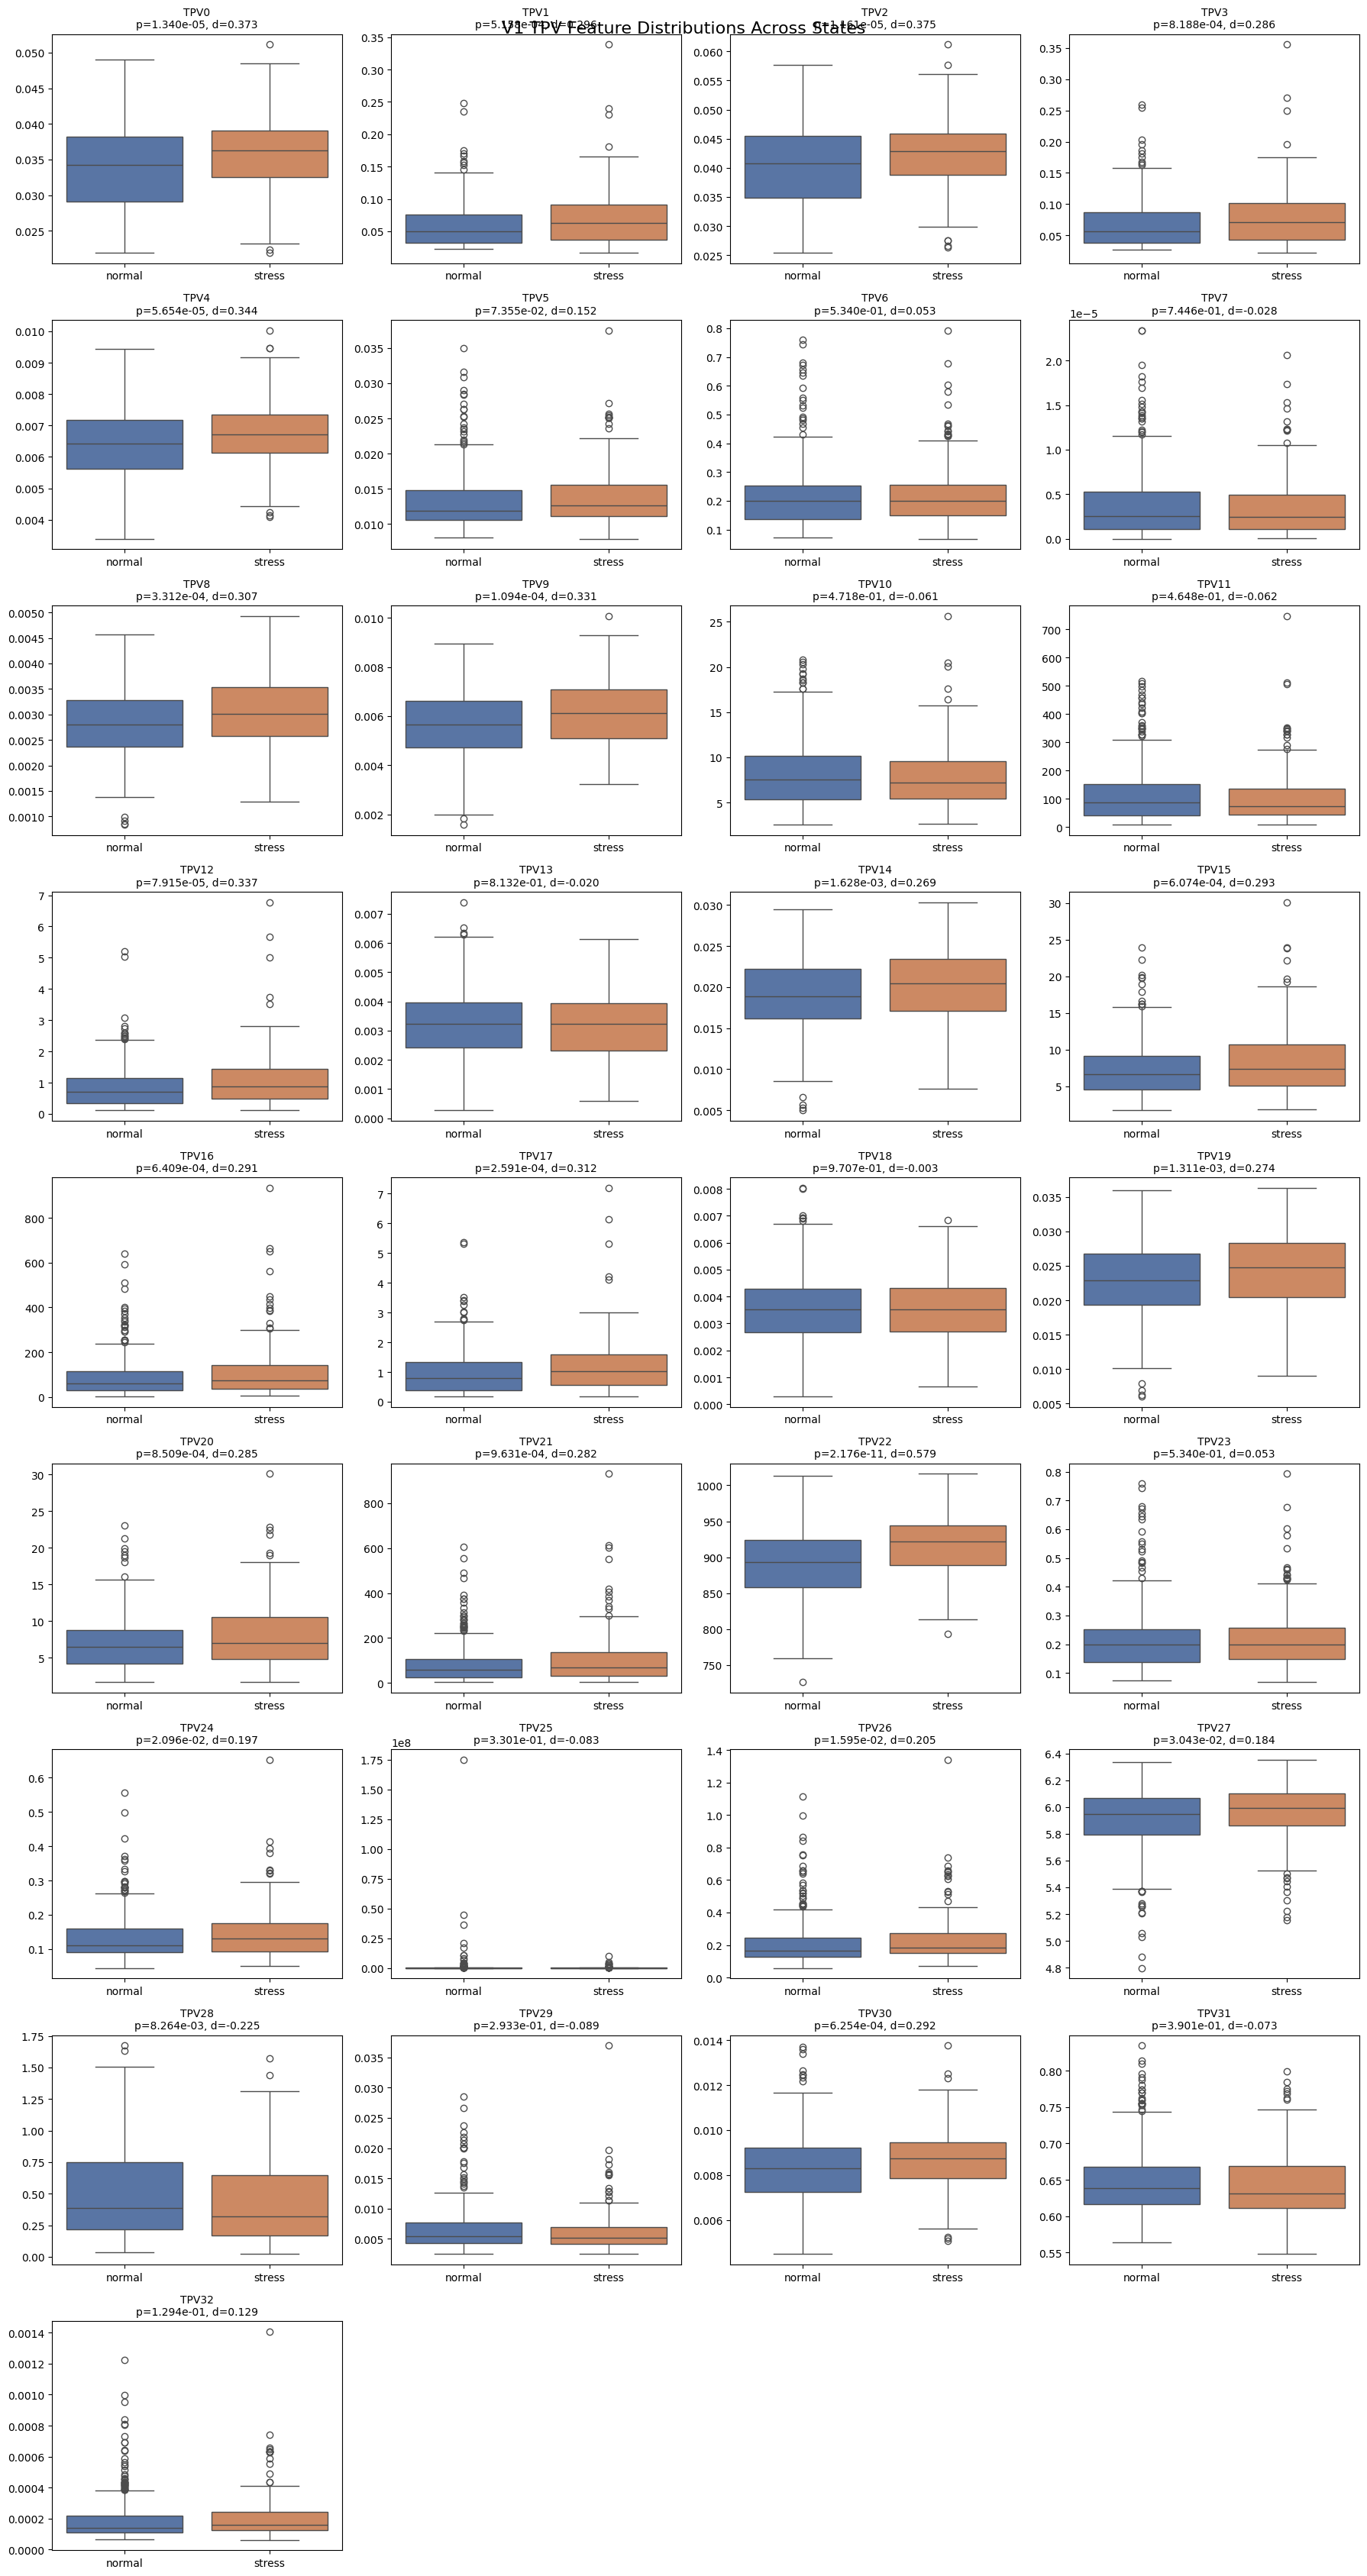


[Saved Figure] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis_V1_TPV/V1_TPV_all_features_boxplots.png
[Saved Table ] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis_V1_TPV/V1_TPV_all_features_overall_anova_effect_size.csv

===== Overall Feature Summary sorted by |Cohen's d| =====
feature              Normal (mean±std)             Stress (mean±std)       direction      anova_p  cohens_d  abs_cohens_d  eta_squared  normal_n  stress_n
  TPV22         888.756871 ± 50.143714        916.397959 ± 41.499766 stress > normal 2.176230e-11  0.578524      0.578524     0.065015       473       196
   TPV2            0.040183 ± 0.006756           0.042628 ± 0.005883 stress > normal 1.161071e-05  0.375321      0.375321     0.028434       473       196
   TPV0            0.033797 ± 0.005765           0.035871 ± 0.005044 stress > normal 1.340471e-05  0.372597      0.372597     0.028035       473       196
   TP

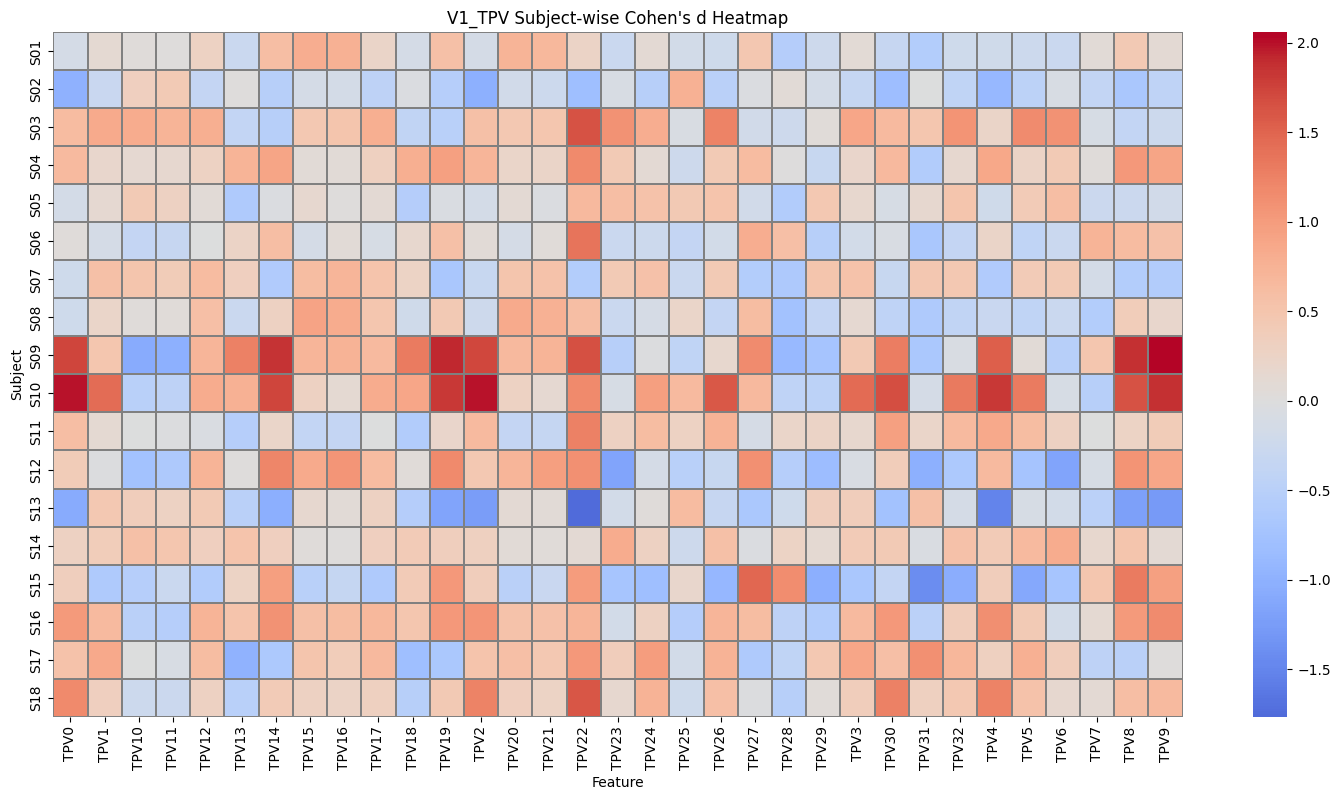

[Saved Heatmap] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis_V1_TPV/V1_TPV_subjectwise_cohens_d_heatmap.png


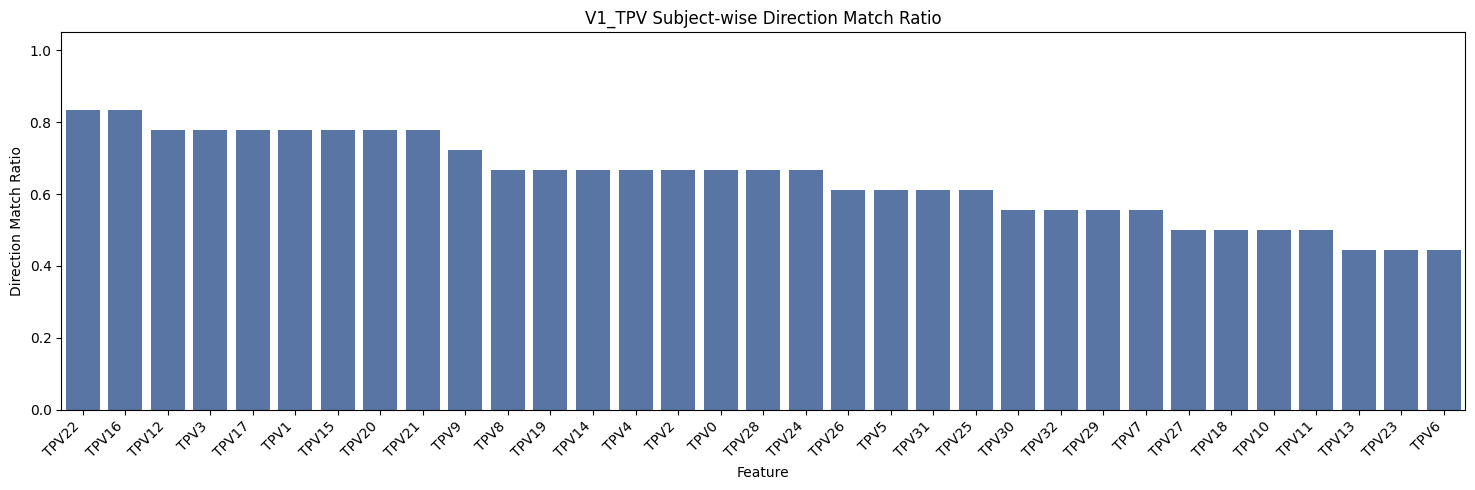

[Saved Direction Match Plot] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis_V1_TPV/V1_TPV_direction_match_ratio_barplot.png


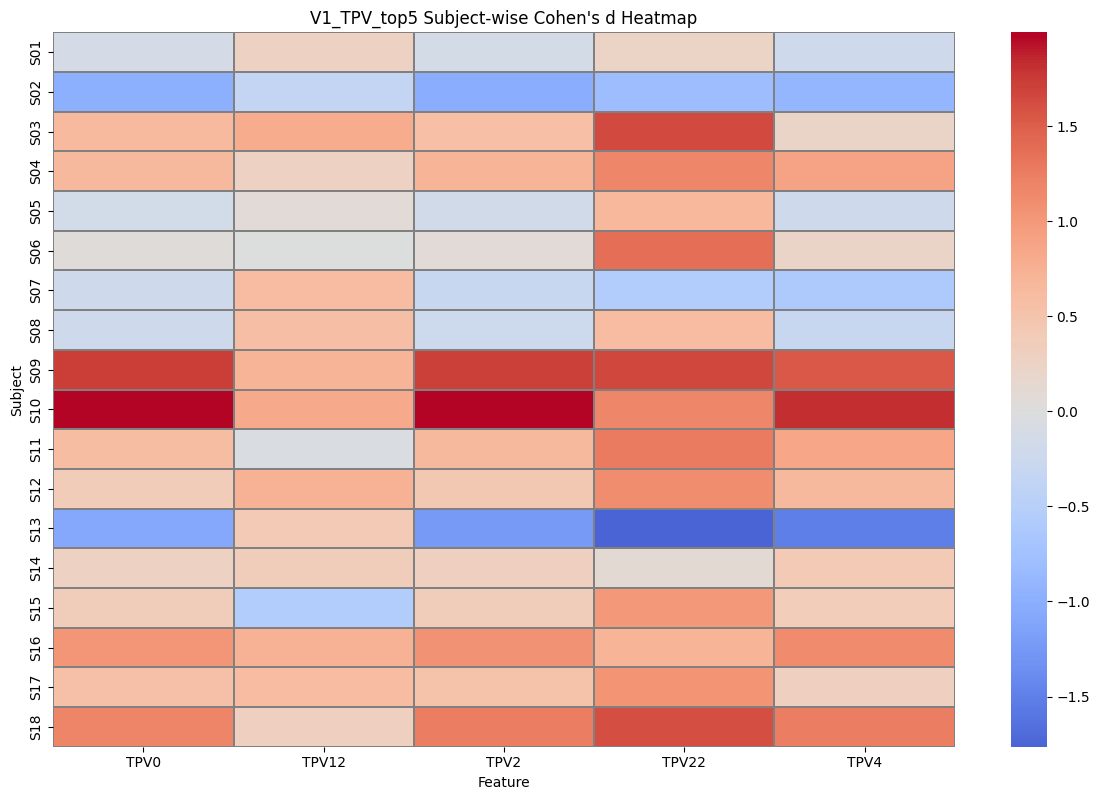

[Saved Heatmap] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis_V1_TPV/V1_TPV_top5_subjectwise_cohens_d_heatmap.png

[Saved Subject-wise Results] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis_V1_TPV/V1_TPV_subjectwise_effect_size.csv
[Saved Direction Summary] /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis_V1_TPV/V1_TPV_subjectwise_direction_summary.csv

Done.


In [1]:
# ============================================================
# TPV Feature Distribution Analysis
# Overall + Subject-wise Effect Size Analysis
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway


# ============================================================
# 0. Path 설정
# ============================================================

TPV_CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/TPV/Wearable_v1_BVP_TPV_noQC.csv"

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/Wearable-Device-Dataset/Feature_Analysis_V1_TPV"
os.makedirs(SAVE_DIR, exist_ok=True)

SUBJECT_COL = "subject"


# ============================================================
# 1. Utility functions
# ============================================================

def prepare_state_column(df):
    df = df.copy()

    if "status_name" in df.columns:
        df["state"] = df["status_name"].replace({
            "normal": "normal",
            "stress": "stress",
            "baseline": "normal"
        })
    elif "status" in df.columns:
        df["state"] = df["status"].map({
            0: "normal",
            1: "stress"
        })
    elif "label_major" in df.columns:
        df["state"] = df["label_major"].map({
            0: "normal",
            1: "stress"
        })
    else:
        raise ValueError("No label column found. Need status_name, status, or label_major.")

    df = df[df["state"].isin(["normal", "stress"])].copy()

    if SUBJECT_COL not in df.columns:
        raise ValueError(f"No subject column found: {SUBJECT_COL}")

    return df


def cohens_d(x1, x2):
    x1 = np.asarray(pd.Series(x1).dropna(), dtype=float)
    x2 = np.asarray(pd.Series(x2).dropna(), dtype=float)

    n1 = len(x1)
    n2 = len(x2)

    if n1 < 2 or n2 < 2:
        return np.nan

    s1 = np.var(x1, ddof=1)
    s2 = np.var(x2, ddof=1)

    pooled_std = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))

    if pooled_std < 1e-12:
        return np.nan

    return (np.mean(x2) - np.mean(x1)) / pooled_std


def eta_squared_anova(groups):
    groups = [np.asarray(pd.Series(g).dropna(), dtype=float) for g in groups]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) < 2:
        return np.nan

    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)

    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = sum((x - grand_mean) ** 2 for x in all_data)

    if ss_total < 1e-12:
        return np.nan

    return ss_between / ss_total


def format_mean_std(mean, std):
    if not np.isfinite(mean):
        return ""
    if not np.isfinite(std):
        std = 0.0
    return f"{mean:.6f} ± {std:.6f}"


# ============================================================
# 2. Overall feature analysis
# ============================================================

def analyze_features_overall(df, features, title, save_prefix, n_cols=4):
    results = []

    n_features = len(features)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 3.8 * n_rows)
    )

    if n_features == 1:
        axes = np.array([axes])

    axes = axes.flatten()

    for i, feature in enumerate(features):
        data = df[["state", feature]].copy()
        data[feature] = pd.to_numeric(data[feature], errors="coerce")
        data = data.dropna()

        normal = data[data["state"] == "normal"][feature]
        stress = data[data["state"] == "stress"][feature]

        if len(normal) < 2 or len(stress) < 2:
            anova_p = np.nan
            d = np.nan
            eta2 = np.nan
        else:
            anova_p = f_oneway(normal, stress).pvalue
            d = cohens_d(normal, stress)
            eta2 = eta_squared_anova([normal, stress])

        normal_mean = normal.mean()
        normal_std = normal.std()
        stress_mean = stress.mean()
        stress_std = stress.std()

        direction = "stress > normal" if stress_mean > normal_mean else "stress < normal"

        results.append({
            "feature": feature,
            "normal_mean": normal_mean,
            "normal_std": normal_std,
            "normal_n": int(len(normal)),
            "stress_mean": stress_mean,
            "stress_std": stress_std,
            "stress_n": int(len(stress)),
            "direction": direction,
            "anova_p": anova_p,
            "cohens_d": d,
            "abs_cohens_d": abs(d) if np.isfinite(d) else np.nan,
            "eta_squared": eta2,
            "Normal (mean±std)": format_mean_std(normal_mean, normal_std),
            "Stress (mean±std)": format_mean_std(stress_mean, stress_std),
        })

        sns.boxplot(
            x="state",
            y=feature,
            data=data,
            ax=axes[i],
            palette=["#4C72B0", "#DD8452"]
        )

        if np.isfinite(anova_p) and np.isfinite(d):
            axes[i].set_title(f"{feature}\np={anova_p:.3e}, d={d:.3f}", fontsize=10)
        else:
            axes[i].set_title(feature, fontsize=10)

        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    for j in range(n_features, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()

    fig_path = os.path.join(SAVE_DIR, f"{save_prefix}_boxplots.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by=["abs_cohens_d", "anova_p"],
        ascending=[False, True]
    ).reset_index(drop=True)

    csv_path = os.path.join(SAVE_DIR, f"{save_prefix}_overall_anova_effect_size.csv")
    results_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

    print(f"\n[Saved Figure] {fig_path}")
    print(f"[Saved Table ] {csv_path}")

    print("\n===== Overall Feature Summary sorted by |Cohen's d| =====")
    display_cols = [
        "feature",
        "Normal (mean±std)",
        "Stress (mean±std)",
        "direction",
        "anova_p",
        "cohens_d",
        "abs_cohens_d",
        "eta_squared",
        "normal_n",
        "stress_n",
    ]
    print(results_df[display_cols].to_string(index=False))

    return results_df


# ============================================================
# 3. Subject-wise feature analysis
# ============================================================

def analyze_features_by_subject(df, features, dataset_tag, feature_type):
    rows = []

    subjects = sorted(df[SUBJECT_COL].dropna().unique())

    print("\n" + "=" * 80)
    print(f"Subject-wise Analysis: {dataset_tag}")
    print("=" * 80)
    print("Subjects:", subjects)

    for subject in subjects:
        df_sub = df[df[SUBJECT_COL] == subject].copy()

        for feature in features:
            data = df_sub[[SUBJECT_COL, "state", feature]].copy()
            data[feature] = pd.to_numeric(data[feature], errors="coerce")
            data = data.dropna()

            normal = data[data["state"] == "normal"][feature]
            stress = data[data["state"] == "stress"][feature]

            normal_n = len(normal)
            stress_n = len(stress)

            normal_mean = normal.mean() if normal_n > 0 else np.nan
            normal_std = normal.std() if normal_n > 1 else np.nan
            stress_mean = stress.mean() if stress_n > 0 else np.nan
            stress_std = stress.std() if stress_n > 1 else np.nan

            if normal_n < 2 or stress_n < 2:
                anova_p = np.nan
                d = np.nan
                eta2 = np.nan
                direction = "insufficient"
            else:
                anova_p = f_oneway(normal, stress).pvalue
                d = cohens_d(normal, stress)
                eta2 = eta_squared_anova([normal, stress])

                direction = (
                    "stress > normal"
                    if stress_mean > normal_mean
                    else "stress < normal"
                )

            rows.append({
                "dataset": dataset_tag,
                "feature_type": feature_type,
                "subject": subject,
                "feature": feature,
                "normal_mean": normal_mean,
                "normal_std": normal_std,
                "normal_n": int(normal_n),
                "stress_mean": stress_mean,
                "stress_std": stress_std,
                "stress_n": int(stress_n),
                "direction": direction,
                "anova_p": anova_p,
                "cohens_d": d,
                "abs_cohens_d": abs(d) if np.isfinite(d) else np.nan,
                "eta_squared": eta2,
                "Normal (mean±std)": format_mean_std(normal_mean, normal_std),
                "Stress (mean±std)": format_mean_std(stress_mean, stress_std),
            })

    result_df = pd.DataFrame(rows)

    csv_path = os.path.join(SAVE_DIR, f"{dataset_tag}_subjectwise_effect_size.csv")
    result_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

    print(f"\n[Saved Subject-wise Table] {csv_path}")

    print("\n===== Subject-wise Top Rows =====")
    print(
        result_df.sort_values(
            ["subject", "abs_cohens_d"],
            ascending=[True, False]
        ).head(50).to_string(index=False)
    )

    return result_df


def summarize_subjectwise_direction(subject_df, overall_df, dataset_tag):
    overall_direction = overall_df[["feature", "direction", "cohens_d", "abs_cohens_d"]].copy()
    overall_direction = overall_direction.rename(columns={
        "direction": "overall_direction",
        "cohens_d": "overall_cohens_d",
        "abs_cohens_d": "overall_abs_cohens_d",
    })

    df = subject_df.merge(overall_direction, on="feature", how="left")

    valid = df[
        df["direction"].isin(["stress > normal", "stress < normal"])
        & df["overall_direction"].isin(["stress > normal", "stress < normal"])
    ].copy()

    valid["direction_match"] = valid["direction"] == valid["overall_direction"]
    valid["positive_effect"] = valid["cohens_d"] > 0
    valid["negative_effect"] = valid["cohens_d"] < 0

    summary = (
        valid.groupby("feature")
        .agg(
            n_subjects_valid=("subject", "nunique"),
            direction_match_count=("direction_match", "sum"),
            direction_match_ratio=("direction_match", "mean"),
            mean_subject_d=("cohens_d", "mean"),
            std_subject_d=("cohens_d", "std"),
            mean_abs_subject_d=("abs_cohens_d", "mean"),
            median_abs_subject_d=("abs_cohens_d", "median"),
            positive_d_count=("positive_effect", "sum"),
            negative_d_count=("negative_effect", "sum"),
            mean_normal_n=("normal_n", "mean"),
            mean_stress_n=("stress_n", "mean"),
        )
        .reset_index()
    )

    summary = summary.merge(overall_direction, on="feature", how="left")

    summary = summary.sort_values(
        ["direction_match_ratio", "mean_abs_subject_d", "overall_abs_cohens_d"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    csv_path = os.path.join(SAVE_DIR, f"{dataset_tag}_subjectwise_direction_summary.csv")
    summary.to_csv(csv_path, index=False, encoding="utf-8-sig")

    print(f"\n[Saved Direction Summary] {csv_path}")

    print("\n===== Subject-wise Direction Consistency Summary =====")
    print(summary.to_string(index=False))

    return summary


# ============================================================
# 4. Visualization
# ============================================================

def plot_subjectwise_heatmap(subject_df, dataset_tag, value_col="cohens_d"):
    pivot = subject_df.pivot_table(
        index="subject",
        columns="feature",
        values=value_col,
        aggfunc="mean"
    )

    if pivot.empty:
        print(f"[WARN] Empty pivot for {dataset_tag}")
        return

    plt.figure(figsize=(max(12, 0.45 * len(pivot.columns)), max(5, 0.45 * len(pivot.index))))

    sns.heatmap(
        pivot,
        cmap="coolwarm",
        center=0,
        annot=False,
        linewidths=0.3,
        linecolor="gray"
    )

    plt.title(f"{dataset_tag} Subject-wise Cohen's d Heatmap")
    plt.xlabel("Feature")
    plt.ylabel("Subject")
    plt.tight_layout()

    fig_path = os.path.join(SAVE_DIR, f"{dataset_tag}_subjectwise_cohens_d_heatmap.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[Saved Heatmap] {fig_path}")


def plot_direction_match_bar(summary_df, dataset_tag):
    if summary_df.empty:
        return

    plot_df = summary_df.sort_values("direction_match_ratio", ascending=False).copy()

    plt.figure(figsize=(max(10, 0.45 * len(plot_df)), 5))

    sns.barplot(
        x="feature",
        y="direction_match_ratio",
        data=plot_df,
        color="#4C72B0"
    )

    plt.ylim(0, 1.05)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Direction Match Ratio")
    plt.xlabel("Feature")
    plt.title(f"{dataset_tag} Subject-wise Direction Match Ratio")
    plt.tight_layout()

    fig_path = os.path.join(SAVE_DIR, f"{dataset_tag}_direction_match_ratio_barplot.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[Saved Direction Match Plot] {fig_path}")


# ============================================================
# 5. Main
# ============================================================

if __name__ == "__main__":

    df_tpv = pd.read_csv(TPV_CSV_PATH)
    df_tpv = prepare_state_column(df_tpv)

    tpv_features = [c for c in df_tpv.columns if c.startswith("TPV")]

    print("\n==============================")
    print("V1 TPV Overall Analysis")
    print("==============================")
    print("TPV CSV:", TPV_CSV_PATH)
    print("Detected TPV features:", tpv_features)
    print("Total TPV features:", len(tpv_features))
    print(df_tpv["state"].value_counts())

    tpv_overall = analyze_features_overall(
        df=df_tpv,
        features=tpv_features,
        title="V1 TPV Feature Distributions Across States",
        save_prefix="V1_TPV_all_features",
        n_cols=4
    )

    tpv_top5 = tpv_overall.head(5)["feature"].tolist()

    print("\n===== V1 TPV Top-5 Features by Overall |Cohen's d| =====")
    print(tpv_top5)

    tpv_top5_path = os.path.join(SAVE_DIR, "V1_TPV_top5_features_by_overall_effect_size.csv")
    tpv_overall.head(5).to_csv(tpv_top5_path, index=False, encoding="utf-8-sig")
    print("[Saved V1 TPV Top-5]", tpv_top5_path)

    tpv_subjectwise = analyze_features_by_subject(
        df=df_tpv,
        features=tpv_features,
        dataset_tag="V1_TPV",
        feature_type="TPV"
    )

    tpv_direction_summary = summarize_subjectwise_direction(
        subject_df=tpv_subjectwise,
        overall_df=tpv_overall,
        dataset_tag="V1_TPV"
    )

    plot_subjectwise_heatmap(tpv_subjectwise, "V1_TPV")
    plot_direction_match_bar(tpv_direction_summary, "V1_TPV")

    tpv_top5_subjectwise = tpv_subjectwise[
        tpv_subjectwise["feature"].isin(tpv_top5)
    ].copy()

    plot_subjectwise_heatmap(tpv_top5_subjectwise, "V1_TPV_top5")

    subjectwise_all_path = os.path.join(SAVE_DIR, "V1_TPV_subjectwise_effect_size.csv")
    direction_summary_all_path = os.path.join(SAVE_DIR, "V1_TPV_subjectwise_direction_summary.csv")

    tpv_subjectwise.to_csv(subjectwise_all_path, index=False, encoding="utf-8-sig")
    tpv_direction_summary.to_csv(direction_summary_all_path, index=False, encoding="utf-8-sig")

    print("\n[Saved Subject-wise Results]", subjectwise_all_path)
    print("[Saved Direction Summary]", direction_summary_all_path)

    print("\nDone.")